
# Exercise

In this notebook, we'll handle missing data in a dataset by imputing missing values with the mean of their respective columns. We will also generate boxplots for visual inspection of the distributions.

### Libraries and Data 

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
df = pd.read_excel('./nutritional_data.xls', engine='xlrd')

### Mean Imputation

This is a simple and effective method to handle missing values. In this method, we replace the missing values with the mean of the column. This method is effective when the data is missing completely at random (MCAR).

In [53]:
# Replace the value 999.99 with NaN to identify as missing data
df.replace(999.99, pd.NA, inplace=True)

# Convert columns to numeric, forcing errors to NaN
df['Grasas_sat'] = pd.to_numeric(df['Grasas_sat'], errors='coerce')
df['Alcohol'] = pd.to_numeric(df['Alcohol'], errors='coerce')
df['Calorías'] = pd.to_numeric(df['Calorías'], errors='coerce')

# Calculate the mean of each column, excluding missing values
mean_grasas_sat = df['Grasas_sat'].mean()
mean_alcohol = df['Alcohol'].mean()
mean_calorias = df['Calorías'].mean()

# Impute missing values with the mean of their respective columns
df['Grasas_sat'] = df['Grasas_sat'].fillna(mean_grasas_sat)
df['Alcohol'] = df['Alcohol'].fillna(mean_alcohol)
df['Calorías'] = df['Calorías'].fillna(mean_calorias)

### Generating boxplots

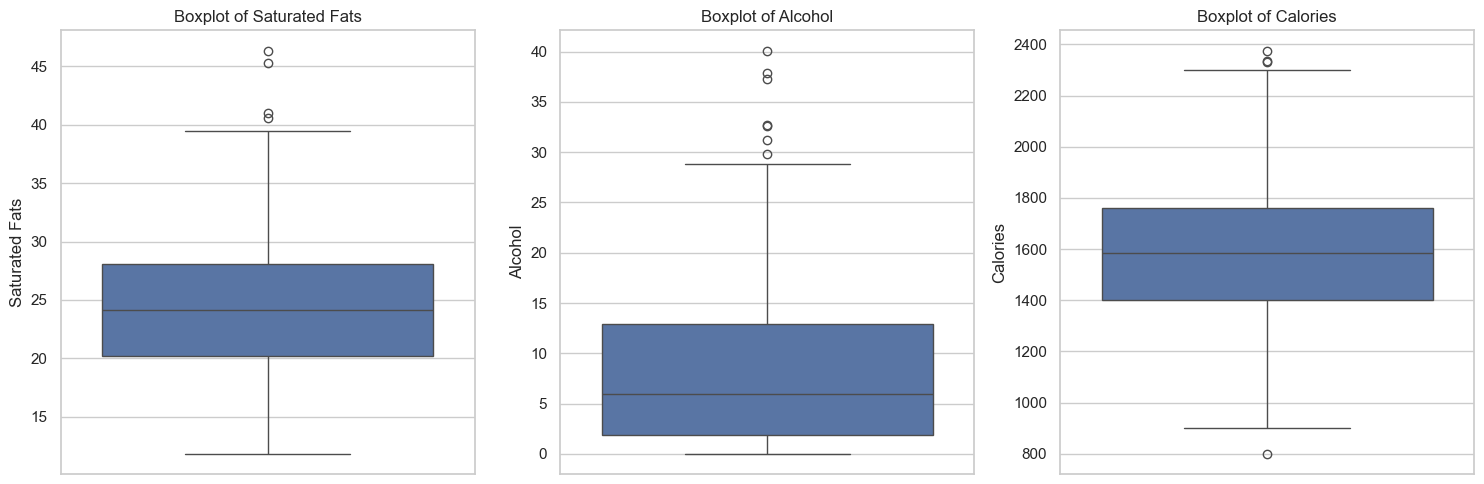

In [54]:
# Set the aesthetic style for the plots
sns.set_theme(style='whitegrid')

# Create boxplots for each column to visualize the distribution
plt.figure(figsize=(15, 5))

# Boxplot for 'Grasas_sat'
plt.subplot(1, 3, 1)
sns.boxplot(df['Grasas_sat'])
plt.title('Boxplot of Saturated Fats')
plt.ylabel('Saturated Fats')

# Boxplot for 'Alcohol'
plt.subplot(1, 3, 2)
sns.boxplot(df['Alcohol'])
plt.title('Boxplot of Alcohol')
plt.ylabel('Alcohol')

# Boxplot for 'Calorías'
plt.subplot(1, 3, 3)
sns.boxplot(df['Calorías'])
plt.title('Boxplot of Calories')
plt.ylabel('Calories')

# Show the plots
plt.tight_layout()
plt.show()


Text(0.5, 1.0, 'Boxplot of Saturated Fats')

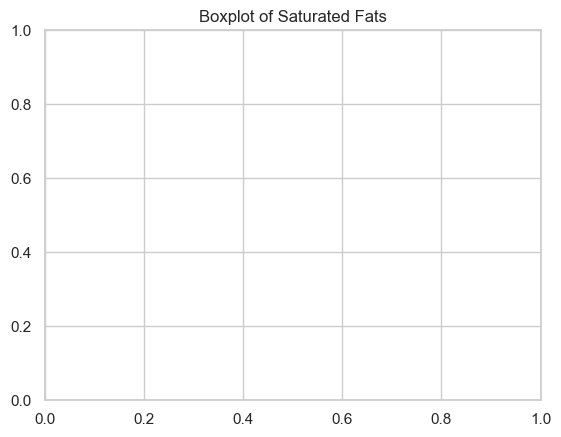

In [55]:
plt.title('Boxplot of Saturated Fats')

# Analysis by sex

## Statistical Summary

First, calculate descriptive statistics for each group defined by Sexo. This includes mean, median, standard deviation, minimum, and maximum values for Grasas_sat, Alcohol, and Calorías.

In [56]:
# Calculate descriptive statistics for each Sexo group
stats_by_sex = df.groupby('Sexo').agg({
    'Grasas_sat': ['mean', 'median', 'std', 'min', 'max'],
    'Alcohol': ['mean', 'median', 'std', 'min', 'max'],
    'Calorías': ['mean', 'median', 'std', 'min', 'max']
})

# Display the statistics
stats_by_sex

Grasas_sat                                       Alcohol         \
           mean     median       std    min    max       mean median   
Sexo                                                                   
F     24.585895  23.980000  6.213704  11.82  41.01   5.906463  4.400   
M     25.003773  24.692151  6.897751  12.71  46.36  12.395154  8.285   

                                Calorías                                 
            std  min    max         mean  median         std  min   max  
Sexo                                                                     
F      5.708925  0.0  18.69  1537.242105  1568.0  269.232863  800  2013  
M     11.059543  0.0  40.11  1642.179487  1610.5  336.587525  923  2376

## Visualization

### Boxplots by Gender

Boxplots are useful for comparing the distribution of Grasas_sat, Alcohol, and Calorías among different Sexo categories. This graph shows the median, quartiles, and potential outliers.

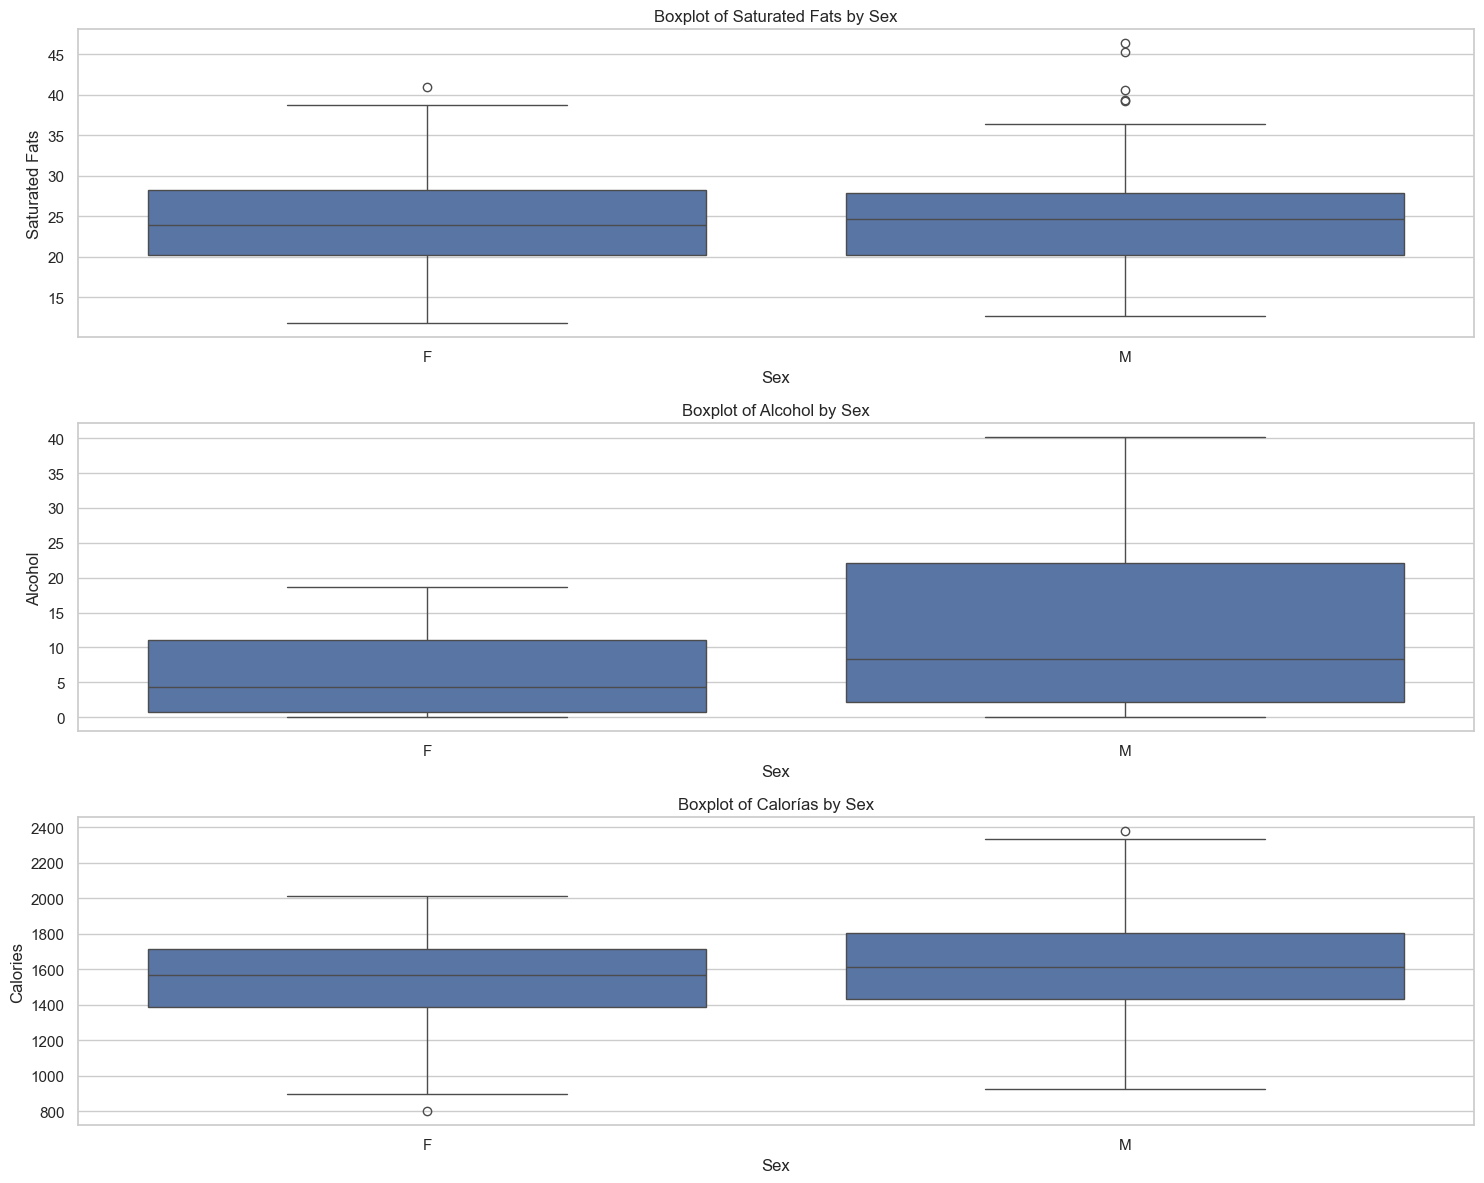

In [57]:
# Create boxplots for each variable categorized by Sexo
plt.figure(figsize=(15, 12))

# Boxplot for 'Grasas_sat'
plt.subplot(3, 1, 1)
sns.boxplot(x='Sexo', y='Grasas_sat', data=df)
plt.title('Boxplot of Saturated Fats by Sex')
plt.xlabel('Sex')
plt.ylabel('Saturated Fats')

# Boxplot for 'Alcohol'
plt.subplot(3, 1, 2)
sns.boxplot(x='Sexo', y='Alcohol', data=df)
plt.title('Boxplot of Alcohol by Sex')
plt.xlabel('Sex')
plt.ylabel('Alcohol')

# Boxplot for 'Calorías'
plt.subplot(3, 1, 3)
sns.boxplot(x='Sexo', y='Calorías', data=df)
plt.title('Boxplot of Calorías by Sex')
plt.xlabel('Sex')
plt.ylabel('Calories')

# Display the plots
plt.tight_layout()
plt.show()


# Analysis by Caloric Categories

### Creating Caloric Categories

First, we'll create a new categorical variable Caloric_Category based on the specified caloric ranges.

In [58]:
# Define the caloric categories
def categorize_calories(cal):
    if cal <= 1100:
        return '1'
    elif cal <= 1700:
        return '2'
    else:
        return '3'

# Apply the categorization function to the 'Calorías' column
df['Caloric_Category'] = df['Calorías'].apply(categorize_calories)

# Display the first few rows to check the new column
df.head()


,Grasas_sat,Alcohol,Calorías,Sexo,Caloric_Category
0,14.60,0.03,910,F,1
1,11.82,0.05,1026,F,1
2,16.98,0.14,1033,F,1
3,14.04,0.38,1098,F,1
4,15.30,0.38,1122,F,2


## Visualization

### Boxplot of Alcohol by Caloric Categories

Boxplots will help us visualize the distribution of Alcohol levels across different caloric categories.

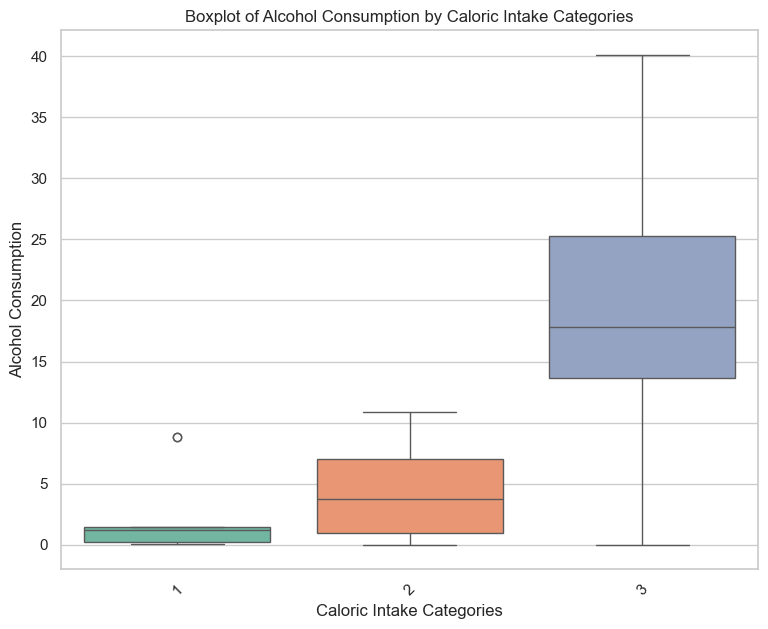

In [59]:
plt.figure(figsize=(9, 7))
sns.boxplot(x='Caloric_Category', y='Alcohol', hue='Caloric_Category', data=df, palette='Set2', legend=False)
plt.xlabel('Caloric Intake Categories')
plt.ylabel('Alcohol Consumption')
plt.title('Boxplot of Alcohol Consumption by Caloric Intake Categories')
plt.xticks(rotation=45)
plt.show()


### Scatterplot of Satuared Fat and Alcohol

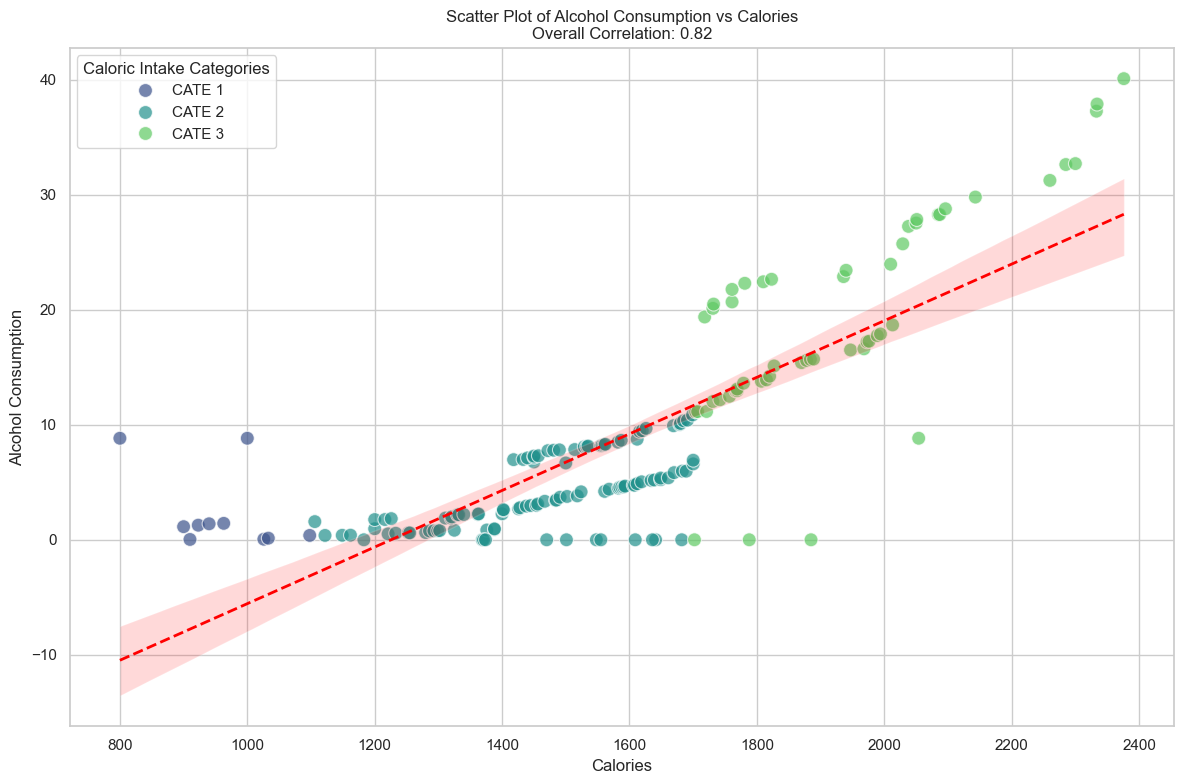

Pearson correlation coefficient: 0.82


In [73]:
# Define caloric categories
conditions = [
    (df['Calorías'] <= 1100),
    (df['Calorías'] > 1100) & (df['Calorías'] <= 1700),
    (df['Calorías'] > 1700)
]
choices = ['CATE 1', 'CATE 2', 'CATE 3']
df['Caloric_Category'] = pd.Categorical(np.select(conditions, choices, default='Unknown'), categories=choices)

# Create the scatter plot
plt.figure(figsize=(12, 8))
sns.scatterplot(x='Calorías', y='Alcohol', hue='Caloric_Category', data=df, palette='viridis', s=100, alpha=0.7)

# Add the overall regression line
sns.regplot(x='Calorías', y='Alcohol', data=df, scatter=False, line_kws={'color': 'red', 'linewidth': 2, 'linestyle': '--'})

# Calculate Pearson correlation coefficient
correlation = df[['Calorías', 'Alcohol']].corr().iloc[0, 1]

# Add titles and labels
plt.xlabel('Calories')
plt.ylabel('Alcohol Consumption')
plt.title(f'Scatter Plot of Alcohol Consumption vs Calories\nOverall Correlation: {correlation:.2f}')

# Show legend
plt.legend(title='Caloric Intake Categories')


# Show the plot
plt.tight_layout()
plt.show()

print(f"Pearson correlation coefficient: {correlation:.2f}")
